In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from matplotlib import colormaps

sys.path.append("C:/Users/haoyu/Documents/GitHub/XRaySimulation")

from XRaySimulation import Pulse, DeviceSimu, util, Crystal

In [9]:
bLattice = np.zeros((11, 11, 11, 360, 3))

bLattice[:,:,:,:,0] = np.arange(-5, 6)[:, np.newaxis, np.newaxis, np.newaxis] * np.pi * 2 / 3.9050 * 1e4
bLattice[:,:,:,:,1] = np.arange(-5, 6)[np.newaxis, :, np.newaxis, np.newaxis] * np.pi * 2 / 3.9050 * 1e4
bLattice[:,:,:,:,2] = np.arange(-5, 6)[np.newaxis, np.newaxis, :, np.newaxis] * np.pi * 2 / 3.9050 * 1e4

tilt_angle = np.deg2rad(0)
tilt_mat = np.array([
    [1, 0, 0,],
    [0, np.cos(tilt_angle), -np.sin(tilt_angle)],
    [0, np.sin(tilt_angle), np.cos(tilt_angle)],
])

for xIdx in range(11):
    for yIdx in range(11):
        for zIdx in range(11):
            for idx in range(360):
                angle = np.deg2rad(idx)
                rot_mat = np.array([[1, 0, 0],
                                    [0, np.cos(angle), -np.sin(angle)],
                                    [0, np.sin(angle), np.cos(angle)],])
                
                bLattice[xIdx, yIdx, zIdx, idx, :] = np.dot(tilt_mat, np.dot(rot_mat, bLattice[xIdx, yIdx, zIdx, idx]))

In [10]:
kLen = util.kev_to_wavevec_length(9.8)
angle = np.deg2rad(11.639) * 2
kvec = np.array([0, -np.sin(angle), np.cos(angle)]) * kLen

tg_angle = np.deg2rad(0.0)
kvec_tg = np.copy(kvec)
kvec_tg[0] += 2 * np.sin(tg_angle) * kLen

In [11]:
kout = bLattice + kvec_tg[np.newaxis, np.newaxis, np.newaxis, np.newaxis]
kout_len = np.linalg.norm(kout, axis=-1)
kout_len_diff = kout_len - kLen

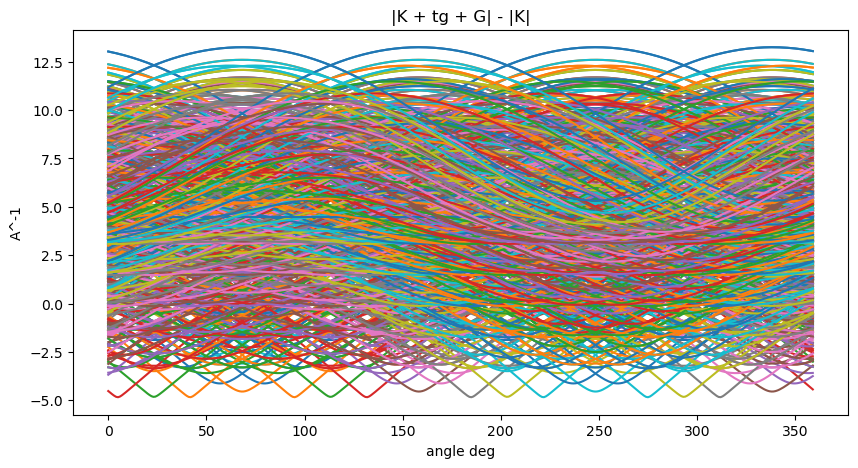

In [12]:
fig, ax = plt.subplots(ncols=1,nrows=1)
cmap = colormaps['summer']

fig.set_figheight(5)
fig.set_figwidth(10)

for xIdx in range(11):
    for yIdx in range(11):
        for zIdx in range(11):
            ax.plot(np.arange(360), kout_len_diff[xIdx, yIdx, zIdx] / 1e4,
                    label="G=({}, {}, {})".format(xIdx, yIdx, zIdx))

plt.title('|K + tg + G| - |K|')
plt.ylabel("A^-1")
plt.xlabel('angle deg')
#plt.legend()
plt.show()

In [22]:
for xIdx in range(11):
    for yIdx in range(11):
        for zIdx in range(11):
            x = np.argmin(np.abs(kout_len_diff[xIdx, yIdx, zIdx] / 1e4))
            k_tmp = kout[xIdx, yIdx, zIdx, x]
            
            if x == 359:
                continue
                            
            if kout_len_diff[xIdx, yIdx, zIdx, x - 1] *  kout_len_diff[xIdx, yIdx, zIdx, x + 1] < 0:
                
                if k_tmp[0] > 0 and k_tmp[1] > 0 and k_tmp[2] > 0:
                    # Normalize the wave-vector
                        direction = k_tmp / np.linalg.norm(k_tmp)
                
                        # Get the position
                        position = direction / direction[2] * 12

                        # Impose the det position limitation
                        if position[0] < 15 and position[1]<18:
                            if xIdx - 5 >= 0 and yIdx - 5>= 0 and zIdx - 5>= 0 :

                                print("G=({}, {}, {})".format(xIdx - 5, yIdx - 5, zIdx - 5), kout[xIdx, yIdx, zIdx, x], x + 1-360)
                                print("detector positoin with respect to the sample in cm", position)
                                print('------------------------------')

G=(1, 1, 1) [16090.10321941  3096.89577079 46811.93789954] -41
detector positoin with respect to the sample in cm [ 4.12461537  0.79387333 12.        ]
------------------------------
G=(1, 1, 2) [16090.10321941 16315.7542867  44010.86990554] -65
detector positoin with respect to the sample in cm [ 4.38712616  4.44865216 12.        ]
------------------------------
G=(1, 2, 1) [16090.10321941 16319.31786104 44092.48917677] -28
detector positoin with respect to the sample in cm [ 4.37900518  4.44138714 12.        ]
------------------------------
G=(1, 2, 2) [16090.10321941 25440.02556402 39287.31757454] -52
detector positoin with respect to the sample in cm [ 4.9145946   7.77045433 12.        ]
------------------------------
G=(1, 2, 3) [16090.10321941 36225.26151444 29932.19245299] -71
detector positoin with respect to the sample in cm [ 6.45062131 14.52293008 12.        ]
------------------------------
G=(1, 3, 2) [16090.10321941 36328.12087468 30303.0913238 ] -48
detector positoin with